# Model Sanity Check

Load all three models, run predictions on 5 personas, verify the numbers in the report.

**Note on reproducibility:** The naive baseline and classical model use GDELT news popularity scores, which are computed from a rolling 30-day window with exponential recency decay. Because the news cycle shifts daily, exact numeric values will differ between runs. The report's numbers (R08) are a point-in-time snapshot. What should be stable across runs: the ranking of models (classical > DL on scrutiny), the naive baseline returning only `general_spending`, and the near-zero Jaccard overlap between classical and DL.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
os.chdir("..")

import pandas as pd
import numpy as np

from scripts.naive_baseline import GDELTPopularityScorer, evaluate_baseline
from scripts.classical import TFIDFRecommender, evaluate
from scripts.deep_learning import HybridNeuralRecommender

contracts = pd.read_csv("data/processed/unified_contracts.csv")
print(f"Loaded {len(contracts):,} contracts, {contracts['topic'].nunique()} topics")

/Users/jonasneves/Github/organizations/civic-lenses.github.io/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 28,267 contracts, 10 topics


In [2]:
PERSONAS = [
    {"name": "Healthcare advocate",  "topics": ["healthcare", "research"]},
    {"name": "Defense watcher",      "topics": ["defense", "government_efficiency"]},
    {"name": "Foreign aid critic",   "topics": ["foreign_aid", "general_spending"]},
    {"name": "Education advocate",   "topics": ["education", "infrastructure"]},
    {"name": "Fiscal accountability","topics": ["government_efficiency", "finance"]},
]
TOP_N = 20

## 1. Naive Baseline (GDELT Popularity)

In [3]:
baseline = GDELTPopularityScorer("data/raw/gdelt_articles.csv")
baseline.fit()

naive_top20 = baseline.recommend(contracts, top_n=TOP_N)
print(f"Naive top-{TOP_N}: {naive_top20['topic'].nunique()} unique topics")
print(f"  Topics: {naive_top20['topic'].value_counts().to_dict()}")
print(f"  Mean scrutiny: {naive_top20['doge_scrutiny_score'].mean():.3f}")
print(f"  Mean value: ${naive_top20['value'].mean():,.0f}")

print("\nPer-persona precision:")
for p in PERSONAS:
    m = evaluate_baseline(naive_top20, p["topics"])
    print(f"  {p['name']}: precision@{TOP_N}={m['precision_at_k']:.3f}, coverage={m['topic_coverage']:.3f}")

Naive top-20: 1 unique topics
  Topics: {'general_spending': 20}
  Mean scrutiny: 0.450
  Mean value: $229,693

Per-persona precision:
  Healthcare advocate: precision@20=0.000, coverage=0.000
  Defense watcher: precision@20=0.000, coverage=0.000
  Foreign aid critic: precision@20=1.000, coverage=0.500
  Education advocate: precision@20=0.000, coverage=0.000
  Fiscal accountability: precision@20=0.000, coverage=0.000


## 2. Classical (TF-IDF + Citizen Impact)

In [4]:
classical = TFIDFRecommender()
classical.fit(contracts)

classical_results = {}
for p in PERSONAS:
    recs = classical.recommend(p["topics"], top_n=TOP_N, alpha=0.7)
    classical_results[p["name"]] = recs

# Aggregate metrics
scrutiny_vals = [r["doge_scrutiny_score"].mean() for r in classical_results.values()]
value_vals = [r["value"].mean() for r in classical_results.values()]
diversity_vals = [r["topic"].nunique() for r in classical_results.values()]

print(f"Classical model (averaged across {len(PERSONAS)} personas):")
print(f"  Mean DOGE scrutiny: {np.mean(scrutiny_vals):.3f}")
print(f"  Mean contract value: ${np.mean(value_vals):,.0f}")
print(f"  Mean topic diversity: {np.mean(diversity_vals):.1f}")

print("\nPer-persona breakdown:")
for p in PERSONAS:
    r = classical_results[p["name"]]
    print(f"  {p['name']}:")
    print(f"    scrutiny={r['doge_scrutiny_score'].mean():.3f}, value=${r['value'].mean():,.0f}, topics={r['topic'].nunique()}")

Classical model (averaged across 5 personas):
  Mean DOGE scrutiny: 0.720
  Mean contract value: $54,278,038
  Mean topic diversity: 2.8

Per-persona breakdown:
  Healthcare advocate:
    scrutiny=0.456, value=$26,967,670, topics=2
  Defense watcher:
    scrutiny=0.645, value=$228,696,510, topics=2
  Foreign aid critic:
    scrutiny=0.796, value=$6,866,104, topics=3
  Education advocate:
    scrutiny=0.826, value=$1,671,134, topics=5
  Fiscal accountability:
    scrutiny=0.875, value=$7,188,771, topics=2


## 3. Deep Learning (Sentence Transformer + MLP Ranker)

In [5]:
dl = HybridNeuralRecommender(device="cpu")
dl.load_artifacts(contracts=contracts)

dl_results = {}
for p in PERSONAS:
    recs = dl.recommend(p["topics"], top_n=TOP_N)
    dl_results[p["name"]] = recs

scrutiny_vals = [r["doge_scrutiny_score"].mean() for r in dl_results.values()]
value_vals = [r["value"].mean() for r in dl_results.values()]
diversity_vals = [r["topic"].nunique() for r in dl_results.values()]

print(f"DL model (averaged across {len(PERSONAS)} personas):")
print(f"  Mean DOGE scrutiny: {np.mean(scrutiny_vals):.3f}")
print(f"  Mean contract value: ${np.mean(value_vals):,.0f}")
print(f"  Mean topic diversity: {np.mean(diversity_vals):.1f}")

print("\nPer-persona breakdown:")
for p in PERSONAS:
    r = dl_results[p["name"]]
    print(f"  {p['name']}:")
    print(f"    scrutiny={r['doge_scrutiny_score'].mean():.3f}, value=${r['value'].mean():,.0f}, topics={r['topic'].nunique()}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 42947.94it/s]


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DL model (averaged across 5 personas):
  Mean DOGE scrutiny: 0.408
  Mean contract value: $49,648,207
  Mean topic diversity: 1.4

Per-persona breakdown:
  Healthcare advocate:
    scrutiny=0.253, value=$23,111,583, topics=1
  Defense watcher:
    scrutiny=0.310, value=$56,873,979, topics=1
  Foreign aid critic:
    scrutiny=0.314, value=$55,621,796, topics=2
  Education advocate:
    scrutiny=0.639, value=$9,153,854, topics=2
  Fiscal accountability:
    scrutiny=0.521, value=$103,479,821, topics=1


## 4. Cross-Model Comparison

In [6]:
# Summary table matching R08
rows = []
for label, results in [("Naive (GDELT)", {p["name"]: naive_top20 for p in PERSONAS}),
                        ("Classical (TF-IDF)", classical_results),
                        ("Deep Learning (MLP)", dl_results)]:
    s = [r["doge_scrutiny_score"].mean() for r in results.values()]
    v = [r["value"].mean() for r in results.values()]
    d = [r["topic"].nunique() for r in results.values()]
    rows.append({
        "Model": label,
        "Mean Scrutiny": f"{np.mean(s):.3f}",
        "Mean Value": f"${np.mean(v):,.0f}",
        "Topic Diversity": f"{np.mean(d):.1f}",
    })

rows.append({
    "Model": "Dataset Baseline",
    "Mean Scrutiny": f"{contracts['doge_scrutiny_score'].mean():.3f}",
    "Mean Value": f"${contracts['value'].mean():,.0f}",
    "Topic Diversity": "-",
})

pd.DataFrame(rows).set_index("Model")

,Mean Scrutiny,Mean Value,Topic Diversity
Model,,,
Naive (GDELT),0.450,"$229,693",1.0
Classical (TF-IDF),0.720,"$54,278,038",2.8
Deep Learning (MLP),0.408,"$49,648,207",1.4
Dataset Baseline,0.383,"$9,622,308",-


## 5. Model Overlap (Jaccard)

In [7]:
overlap_rows = []
for p in PERSONAS:
    c_ids = set(classical_results[p["name"]]["contract_id"])
    d_ids = set(dl_results[p["name"]]["contract_id"])
    jaccard = len(c_ids & d_ids) / len(c_ids | d_ids) if (c_ids | d_ids) else 0
    overlap_rows.append({
        "Persona": p["name"],
        "Topics": ", ".join(p["topics"]),
        "Jaccard": f"{jaccard:.3f}",
        "Shared": len(c_ids & d_ids),
    })

pd.DataFrame(overlap_rows).set_index("Persona")

,Topics,Jaccard,Shared
Persona,,,
Healthcare advocate,"healthcare, research",0.000,0
Defense watcher,"defense, government_efficiency",0.053,2
Foreign aid critic,"foreign_aid, general_spending",0.026,1
Education advocate,"education, infrastructure",0.000,0
Fiscal accountability,"government_efficiency, finance",0.176,6


## 6. Sample Recommendations (Healthcare Advocate)

In [8]:
SHOW_COLS = ["contract_id", "agency", "topic", "doge_scrutiny_score", "value", "description"]
persona = "Healthcare advocate"

print("=== NAIVE BASELINE (same for all users) ===")
display(naive_top20[SHOW_COLS].head(5))

print("\n=== CLASSICAL (TF-IDF) ===")
display(classical_results[persona][SHOW_COLS].head(5))

print("\n=== DEEP LEARNING (MLP) ===")
display(dl_results[persona][SHOW_COLS].head(5))

=== NAIVE BASELINE (same for all users) ===


,contract_id,agency,topic,doge_scrutiny_score,value,description
0,DOGE_L_000263,USDA APHIS,general_spending,0.0,212927.00,Agency Identified Terminations
1,DOGE_C_009150,National Aeronautics and Space Administration,general_spending,0.0,659225.96,Conducting evidence and evaluation activities ...
2,DOGE_G_009402,National Endowment for the Humanities,general_spending,1.0,60000.00,Research and writing leading to a book on sexu...
3,DOGE_G_009401,National Endowment for the Humanities,general_spending,1.0,60000.00,Research and writing leading to a book on 19th...
4,DOGE_C_009143,International Assistance Programs,general_spending,0.0,60376.66,TASK ORDER: CRUCIAL CONVERSATIONS - DFC-WIDE T...



=== CLASSICAL (TF-IDF) ===


,contract_id,agency,topic,doge_scrutiny_score,value,description
0,DOGE_G_012845,Department of Health and Human Services,healthcare,0.000123,1.025847e+07,Wits HIV Research Group CLINICAL TRIAL UNIT (C...
1,DOGE_C_008410,Department of the Interior,general_spending,0.000000,2.260925e+07,CLINICAL TRIAL REPORTING PROGRAM SUPPORT SERVICES
2,DOGE_C_005418,Department of Veterans Affairs,healthcare,1.000000,9.500000e+04,Community Nursing Home Services by Hospital Le...
3,DOGE_C_013091,Department of Health and Human Services,healthcare,0.000000,3.171483e+08,HEALTH BASIC RESEARCH: CLINICAL SERVICES NETWO...
4,DOGE_C_012643,Department of Health and Human Services,healthcare,0.000000,1.135800e+06,PHARMACEUTICAL PREPARATION MANUFACTURING: FEAS...



=== DEEP LEARNING (MLP) ===


,contract_id,agency,topic,doge_scrutiny_score,value,description
0,DOGE_G_003033,Department of Health and Human Services,healthcare,0.240132,5394452.0,The proposed University of Washington (UW) Vac...
1,DOGE_G_003626,Department of Health and Human Services,healthcare,0.095852,9616028.0,The proposed University of Washington (UW) Vac...
2,DOGE_G_004195,Department of Health and Human Services,healthcare,0.438539,1561928.0,The proposed University of Washington (UW) Vac...
3,DOGE_G_003891,Department of Health and Human Services,healthcare,0.065173,12203207.0,Project Summary/Abstract The currently NIAID-f...
4,DOGE_G_003334,Department of Health and Human Services,healthcare,0.069851,14870022.0,Project Summary/Abstract The currently NIAID-f...


## 7. DL Ranker Score Distribution

The MLP output is unbounded (no activation on the final layer). Top-N recommendations are positive, but rejected candidates can be negative. This shows the ranker learned to separate.

Candidate pool: 200 contracts
Score range: [-0.2572, 0.2734]
Mean: -0.0382, Median: -0.0352
Negative scores: 143 / 200 (72%)
Top-20 cutoff: 0.0302


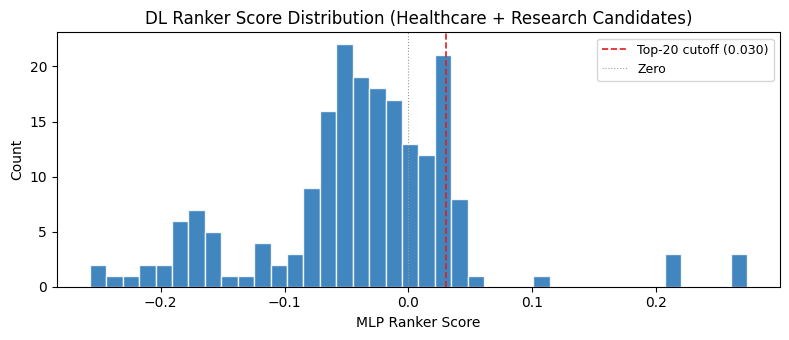

In [9]:
import torch
from scripts.deep_learning import RANKER_FEATURES

# Score ALL candidates for one persona (not just top-N)
user_topics = ["healthcare", "research"]
per_topic = max(dl.candidate_pool // len(user_topics), 20)
cand_set, topic_sims = set(), {}

for topic in user_topics:
    from scripts.deep_learning import TOPIC_KEYWORDS
    t_text = TOPIC_KEYWORDS.get(topic, topic)
    t_emb = dl.encoder.encode(t_text, normalize_embeddings=True)
    t_sims = dl._embeddings @ t_emb
    for idx in np.argsort(t_sims)[::-1][:per_topic]:
        cand_set.add(int(idx))
        topic_sims[int(idx)] = max(topic_sims.get(int(idx), -1), t_sims[idx])

cand_idx = np.array(sorted(cand_set))
df_cand = dl._contracts.iloc[cand_idx].copy()
df_cand["embedding_similarity"] = [topic_sims[int(i)] for i in cand_idx]
df_cand["topic_match"] = df_cand["topic"].apply(lambda t: 1.0 if t in user_topics else 0.0)
max_log_val = np.log1p(dl._contracts["value"].max()) or 1.0
df_cand["log_value"] = np.log1p(df_cand["value"].values) / max_log_val
max_dlen = dl._contracts["description_length"].max() or 1
df_cand["norm_description_length"] = df_cand["description_length"].values / max_dlen
for col in RANKER_FEATURES:
    df_cand[col] = df_cand[col].fillna(0)

feats = df_cand[RANKER_FEATURES].values.astype(np.float32)
feats_scaled = dl.scaler.transform(feats)
with torch.no_grad():
    all_scores = dl.ranker(torch.tensor(feats_scaled, dtype=torch.float32)).cpu().numpy().flatten()

print(f"Candidate pool: {len(all_scores)} contracts")
print(f"Score range: [{all_scores.min():.4f}, {all_scores.max():.4f}]")
print(f"Mean: {all_scores.mean():.4f}, Median: {np.median(all_scores):.4f}")
print(f"Negative scores: {(all_scores < 0).sum()} / {len(all_scores)} ({(all_scores < 0).mean()*100:.0f}%)")
print(f"Top-20 cutoff: {np.sort(all_scores)[::-1][19]:.4f}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(all_scores, bins=40, color="#2171b5", edgecolor="white", alpha=0.85)
cutoff = np.sort(all_scores)[::-1][19]
ax.axvline(cutoff, color="#e31a1c", linestyle="--", linewidth=1.2, label=f"Top-20 cutoff ({cutoff:.3f})")
ax.axvline(0, color="#999", linestyle=":", linewidth=0.8, label="Zero")
ax.set_xlabel("MLP Ranker Score")
ax.set_ylabel("Count")
ax.set_title("DL Ranker Score Distribution (Healthcare + Research Candidates)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()